<a href="https://colab.research.google.com/github/rirfan3689/CSCI323-Spam-Detection/blob/main/notebooks/11_cross_validation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
import numpy as np
from scipy.sparse import load_npz

uploaded = files.upload()  # Upload 4 files:
                           # X_train.npz, y_train.npy
                           # X_test.npz, y_test.npy

X_train = load_npz('X_train.npz')
X_test = load_npz('X_test.npz')
y_train = np.load('y_train.npy', allow_pickle=True)
y_test = np.load('y_test.npy', allow_pickle=True)

print("Training shape:", X_train.shape)
print("Test shape:", X_test.shape)

Saving X_test.npz to X_test.npz
Saving X_train.npz to X_train.npz
Saving y_test.npy to y_test.npy
Saving y_train.npy to y_train.npy
Training shape: (4135, 5000)
Test shape: (1034, 5000)


In [2]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
import matplotlib.pyplot as plt
import numpy as np
import json

print("Libraries loaded!")

Libraries loaded!


In [3]:
models = {
    'Naive Bayes': MultinomialNB(),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'SVM': SVC(kernel='linear', random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42)
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("Models and CV strategy defined!")
print("Strategy: 5-Fold Stratified Cross Validation")

Models and CV strategy defined!
Strategy: 5-Fold Stratified Cross Validation


In [4]:
print("=== 5-Fold Cross Validation — UCI SMS Dataset ===\n")

cv_results = {}

for name, model in models.items():
    print(f"Running CV for {name}...")
    scores = cross_val_score(model, X_train, y_train,
                            cv=cv, scoring='f1_macro')
    cv_results[name] = {
        'mean': round(float(scores.mean()), 4),
        'std': round(float(scores.std()), 4),
        'scores': [round(float(s), 4) for s in scores]
    }
    print(f"  F1 per fold: {cv_results[name]['scores']}")
    print(f"  Mean F1:     {cv_results[name]['mean']}")
    print(f"  Std Dev:     {cv_results[name]['std']}\n")

=== 5-Fold Cross Validation — UCI SMS Dataset ===

Running CV for Naive Bayes...
  F1 per fold: [0.8832, 0.9056, 0.9232, 0.8844, 0.8568]
  Mean F1:     0.8906
  Std Dev:     0.0225

Running CV for Logistic Regression...
  F1 per fold: [0.8568, 0.8663, 0.8993, 0.8715, 0.7994]
  Mean F1:     0.8587
  Std Dev:     0.0328

Running CV for SVM...
  F1 per fold: [0.9273, 0.9497, 0.9568, 0.9474, 0.9227]
  Mean F1:     0.9408
  Std Dev:     0.0133

Running CV for Random Forest...
  F1 per fold: [0.9092, 0.9334, 0.9334, 0.9213, 0.878]
  Mean F1:     0.915
  Std Dev:     0.0206



In [5]:
# Load baseline results
baseline_files = {
    'Naive Bayes': 'nb_results.json',
    'Logistic Regression': 'lr_results.json',
    'SVM': 'svm_results.json',
    'Random Forest': 'rf_results.json'
}

uploaded2 = files.upload()  # Upload 4 JSON files:
                            # nb_results.json, lr_results.json
                            # svm_results.json, rf_results.json

baseline = {}
for name, filename in baseline_files.items():
    with open(filename) as f:
        data = json.load(f)
        baseline[name] = data['f1']

print("=== Baseline vs Cross Validation F1 Comparison ===\n")
print(f"{'Model':<25} {'Baseline F1':<15} {'CV Mean F1':<15} {'CV Std':<10} {'Stable?':<10}")
print("-" * 75)

for name in models.keys():
    b_f1 = baseline[name]
    cv_mean = cv_results[name]['mean']
    cv_std = cv_results[name]['std']
    stable = "✅ Yes" if cv_std < 0.03 else "⚠️ No"
    print(f"{name:<25} {b_f1:.4f}{'':>5} {cv_mean:.4f}{'':>5} {cv_std:.4f}{'':>3} {stable}")

print("\nNote: Lower Std Dev = More stable and reliable model")

Saving nb_results.json to nb_results.json
Saving lr_results.json to lr_results.json
Saving svm_results.json to svm_results.json
Saving rf_results.json to rf_results.json
=== Baseline vs Cross Validation F1 Comparison ===

Model                     Baseline F1     CV Mean F1      CV Std     Stable?   
---------------------------------------------------------------------------
Naive Bayes               0.8559      0.8906      0.0225    ✅ Yes
Logistic Regression       0.7798      0.8587      0.0328    ⚠️ No
SVM                       0.8988      0.9408      0.0133    ✅ Yes
Random Forest             0.8833      0.9150      0.0206    ✅ Yes

Note: Lower Std Dev = More stable and reliable model


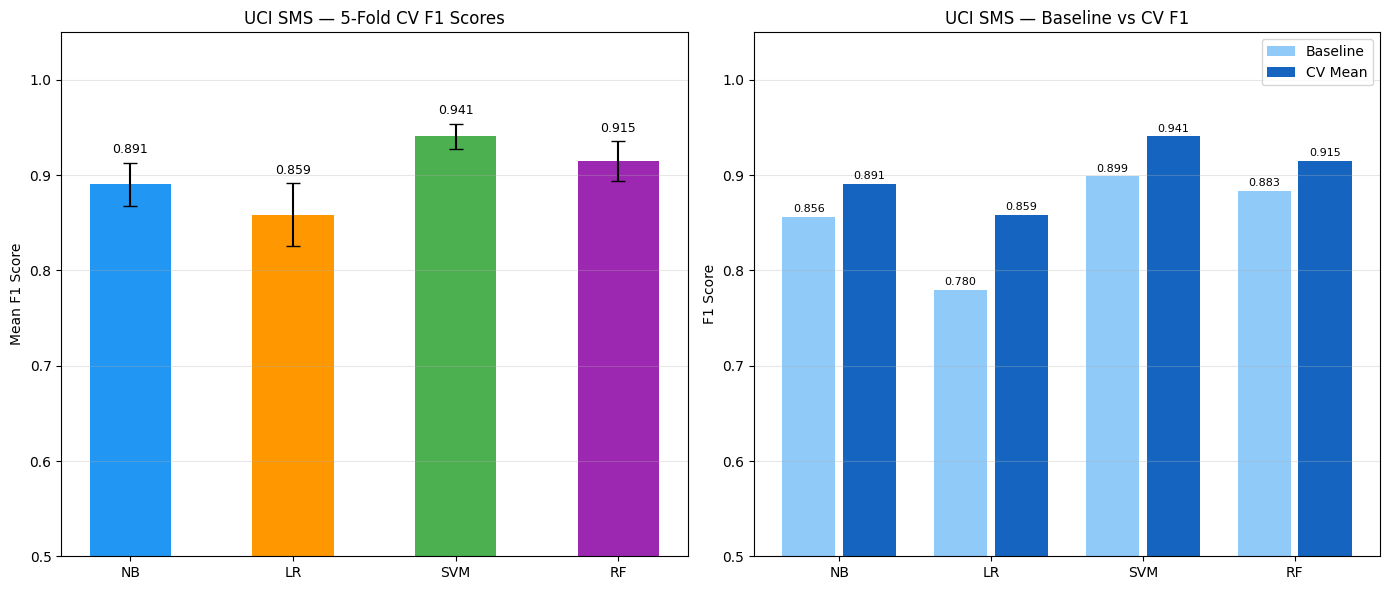

In [6]:
model_names = list(models.keys())
short_names = ['NB', 'LR', 'SVM', 'RF']
x = np.arange(len(model_names))
colors = ['#2196F3', '#FF9800', '#4CAF50', '#9C27B0']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# CV Mean F1 with error bars
cv_means = [cv_results[m]['mean'] for m in model_names]
cv_stds = [cv_results[m]['std'] for m in model_names]

axes[0].bar(x, cv_means, 0.5, yerr=cv_stds,
            capsize=5, color=colors)
axes[0].set_title('UCI SMS — 5-Fold CV F1 Scores')
axes[0].set_xticks(x)
axes[0].set_xticklabels(short_names)
axes[0].set_ylim(0.5, 1.05)
axes[0].set_ylabel('Mean F1 Score')
axes[0].grid(axis='y', alpha=0.3)
for i, (mean, std) in enumerate(zip(cv_means, cv_stds)):
    axes[0].text(i, mean + std + 0.01,
                f'{mean:.3f}', ha='center', fontsize=9)

# Baseline vs CV comparison
baseline_f1 = [baseline[m] for m in model_names]
axes[1].bar(x - 0.2, baseline_f1, 0.35,
            label='Baseline', color='#90CAF9')
axes[1].bar(x + 0.2, cv_means, 0.35,
            label='CV Mean', color='#1565C0')
axes[1].set_title('UCI SMS — Baseline vs CV F1')
axes[1].set_xticks(x)
axes[1].set_xticklabels(short_names)
axes[1].set_ylim(0.5, 1.05)
axes[1].set_ylabel('F1 Score')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)
for i, (b, c) in enumerate(zip(baseline_f1, cv_means)):
    axes[1].text(i - 0.2, b + 0.005,
                f'{b:.3f}', ha='center', fontsize=8)
    axes[1].text(i + 0.2, c + 0.005,
                f'{c:.3f}', ha='center', fontsize=8)

plt.tight_layout()
plt.savefig('cv_results.png')
plt.show()

In [7]:
with open('cv_results.json', 'w') as f:
    json.dump(cv_results, f)

print("Cross validation results saved!")
print("\nSummary:")
for name, results in cv_results.items():
    print(f"  {name}: Mean F1={results['mean']}, Std={results['std']}")

Cross validation results saved!

Summary:
  Naive Bayes: Mean F1=0.8906, Std=0.0225
  Logistic Regression: Mean F1=0.8587, Std=0.0328
  SVM: Mean F1=0.9408, Std=0.0133
  Random Forest: Mean F1=0.915, Std=0.0206
